In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from torch import nn
from torch.nn import functional
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
from google.colab import drive

- PyTorch has two primitives to work with data: **torch.utils.data.DataLoader** and **torch.utils.data.Dataset**. **Dataset** stores the samples and their corresponding labels, and **DataLoader** wraps an iterable around the Dataset.

- CIFAR100 (https://www.cs.toronto.edu/~kriz/cifar.html) of TorchVision ia a dataset already included in the library



In [3]:
# Define data transformation to be applied
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 128
num_workers = 0

#Download training data from open datasets.
trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
print(trainset.data.shape)

# # Download test data from open datasets.
testset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
print(testset.data.shape)


100%|██████████| 169M/169M [00:13<00:00, 12.2MB/s]


(50000, 32, 32, 3)
(10000, 32, 32, 3)


- Loading and inspecting the dataset

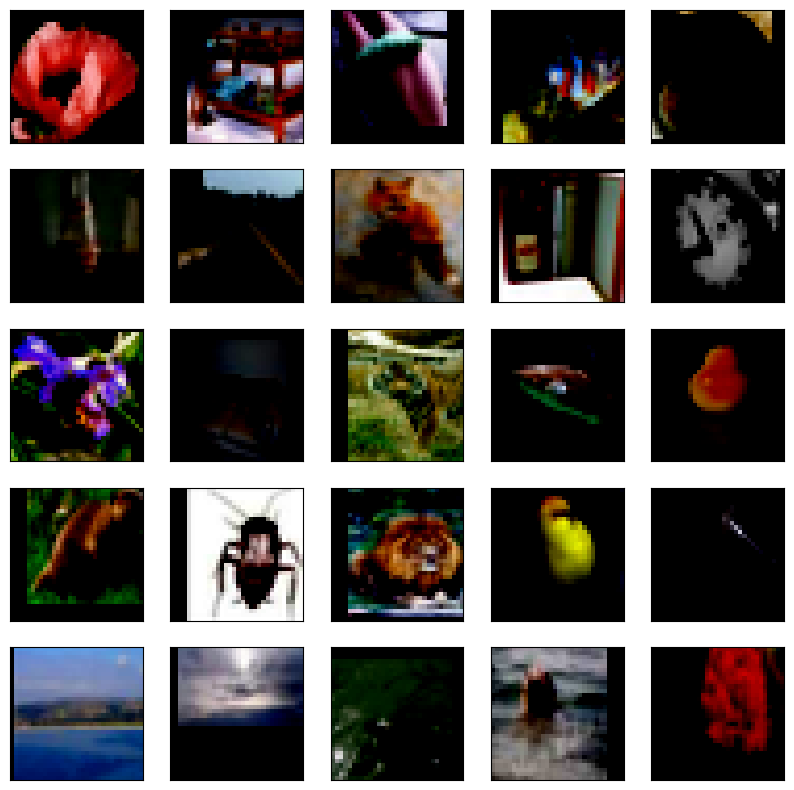

In [4]:
fig , axes = subplots(5, 5, figsize=(10,10))
rng = np.random.default_rng(3)
indices = rng.choice(np.arange(len(trainset)), 25,
replace=False).reshape((5,5))
for i in range(5):
    for j in range(5):
        idx = indices[i,j]
        axes[i,j].imshow(np.transpose(trainset[idx][0],
                                      [1,2,0]),
                                      interpolation=None)
        axes[i,j].set_xticks ([])
        axes[i,j].set_yticks ([])

- Dataloader for
    - Batching the data
    - Shuffling the data
    - Load the data in parallel using multiprocessing workers.

In [5]:
#Train
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

#Test
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

- Model

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 100)

    def forward(self, x):
        x = self.pool(functional.relu(self.conv1(x)))
        x = self.pool(functional.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = functional.relu(self.fc1(x))
        x = functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x



- Training procedure

In [7]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train() # set the model to train instead of prediction (model.eval())
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device) # sends the tensors to the devices

        # Compute prediction error - Forward pass
        pred = model.forward(X) # also model(X)
        loss = loss_fn.forward(pred, y) # loss computation

        # Backpropagation - Backward pass
        loss.backward() # gradient computation
        optimizer.step() # parameters update
        optimizer.zero_grad() # clear gradients for the next iteration

        total_loss += loss.item() # loss.item() gets the numerical loss value

        # if batch % 100 == 0:
        #     loss, current = loss.item(), (batch + 1) * len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    avg_loss = total_loss / len(dataloader)
    return avg_loss

Validate Train

In [8]:
def validate(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss = 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            total_loss += loss.item()

    # Calculate the average loss over all batches
    avg_loss = total_loss / len(dataloader)
    return avg_loss

- Training

In [9]:
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

True
Using device: cuda


In [11]:
model = Net().to(device)
print(model)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

epochs = 100
patience = 10

best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []
for t in range(epochs):

    #train(train_income_dataloader, model, loss_fn, optimizer)
    epoch_loss = train(trainloader, model, loss_fn, optimizer, device)
    val_loss = validate(testloader, model, loss_fn, device)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if (t + 1) % 5 == 0 or t == 0:
        print(f"Epoch {t+1}\n-------------------------------")
        print(f"Epoch {t+1} Average Loss: {epoch_loss:>7f}")
        print(f"Validate: {val_loss:>7f}")

     # Lógica de Early Stopping:
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Early Stopping] A perda de validação não melhora há {patience} épocas.")
            print(f"Interrompendo o treinamento na época {t+1}.")
            break
print("Done!")

# Recovering model parameters
# print(model.linear.weight.item())
# torch.save(model.state_dict(), "model.pth")
# torch.load("model.pth")

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=100, bias=True)
)
Epoch 1
-------------------------------
Epoch 1 Average Loss: 4.558296
Validate: 4.405486
Epoch 5
-------------------------------
Epoch 5 Average Loss: 3.589928
Validate: 3.544821
Epoch 10
-------------------------------
Epoch 10 Average Loss: 3.246559
Validate: 3.141027
Epoch 15
-------------------------------
Epoch 15 Average Loss: 3.066894
Validate: 3.029712
Epoch 20
-------------------------------
Epoch 20 Average Loss: 2.956270
Validate: 2.901848
Epoch 25
-------------------------------
Epoch 25 Average Loss: 2.876155
Validate: 2.885214
Epoch 30
-------------------------------
Epoch 30 Average

Reference:

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

Grafic

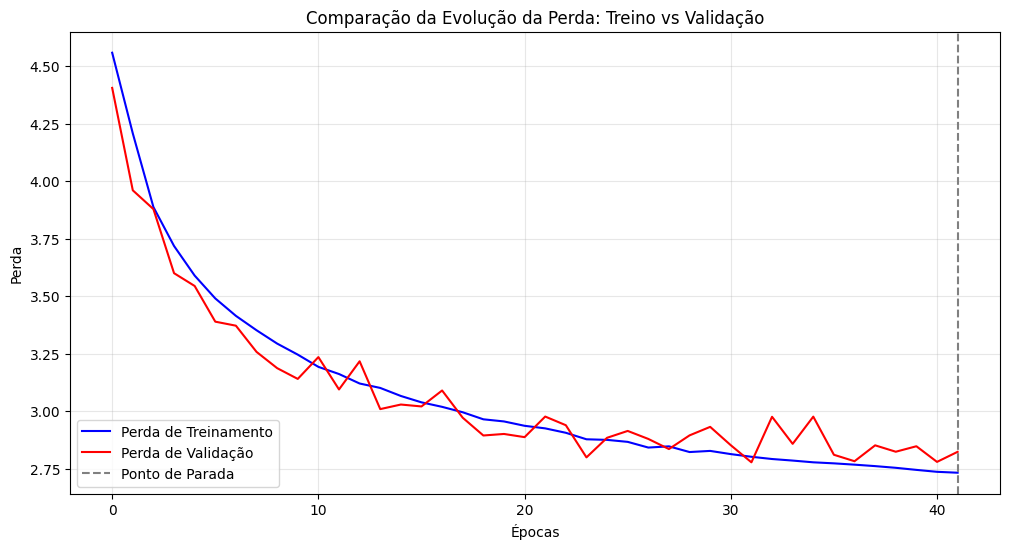

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Perda de Treinamento', color='blue')
plt.plot(val_losses, label='Perda de Validação', color='red')

# identify the early stopping point on the chart
plt.axvline(x=len(train_losses)-1, color='gray', linestyle='--', label='Ponto de Parada')

plt.title('Comparação da Evolução da Perda: Treino vs Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()